# Malware Detection Using Machine Learning — Reproduction & Critical Evaluation

**Student:** Fairuz Khalil  
**Course:** Data Science in Cyber — Final Project (Dr. Uri Itai)

**Source article reproduced:** [emr4h/Malware-Detection-Using-Machine-Learning](https://github.com/emr4h/Malware-Detection-Using-Machine-Learning)

---
**How to run:** select **Kernel → Restart & Run All**. The notebook will automatically create `data-set/` and `figures/` directories and download `MalwareDataSet.csv` from the source repository if it is not already present. All results shown in `report.pdf` were produced by running this notebook with `RANDOM_SEED = 42`.
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score, average_precision_score,
    matthews_corrcoef, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
import pathlib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Create output directories so all savefig calls succeed
pathlib.Path("figures").mkdir(exist_ok=True)
pathlib.Path("data-set").mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


## 1. Data Loading

In [2]:
import urllib.request

_CSV_URL = (
    "https://raw.githubusercontent.com/emr4h/"
    "Malware-Detection-Using-Machine-Learning/main/data-set/MalwareDataSet.csv"
)
_CSV_PATH = pathlib.Path("data-set/MalwareDataSet.csv")

if not _CSV_PATH.exists():
    print("Dataset not found locally — downloading from source repository...")
    urllib.request.urlretrieve(_CSV_URL, _CSV_PATH)
    print(f"Saved to {_CSV_PATH}")
else:
    print(f"Using cached dataset at {_CSV_PATH}")

df = pd.read_csv(_CSV_PATH)
print(f"Shape: {df.shape}")
df.head()


Dataset not found locally — downloading from source repository...
Saved to data-set\MalwareDataSet.csv
Shape: (137444, 9)


,AddressOfEntryPoint,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,SizeOfStackReserve,NumberOfSections,ResourceSize,legitimate
0,10407,9,6,6,33088,262144,4,952,1
1,5354,9,6,6,33088,262144,4,952,1
2,58807,9,6,6,33088,262144,4,136490,1
3,25166,9,6,6,33088,262144,4,1940,1
4,70387,9,6,6,33088,262144,4,83098,1


In [3]:
# Data types and basic structure
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 137444 entries, 0 to 137443
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   AddressOfEntryPoint          137444 non-null  int64
 1   MajorLinkerVersion           137444 non-null  int64
 2   MajorImageVersion            137444 non-null  int64
 3   MajorOperatingSystemVersion  137444 non-null  int64
 4   DllCharacteristics           137444 non-null  int64
 5   SizeOfStackReserve           137444 non-null  int64
 6   NumberOfSections             137444 non-null  int64
 7   ResourceSize                 137444 non-null  int64
 8   legitimate                   137444 non-null  int64
dtypes: int64(9)
memory usage: 9.4 MB


In [4]:
# Size, feature types
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print()
print("Feature dtypes:")
print(df.dtypes)


Rows: 137,444   Columns: 9

Feature dtypes:
AddressOfEntryPoint            int64
MajorLinkerVersion             int64
MajorImageVersion              int64
MajorOperatingSystemVersion    int64
DllCharacteristics             int64
SizeOfStackReserve             int64
NumberOfSections               int64
ResourceSize                   int64
legitimate                     int64
dtype: object


**Temporal analysis.** This dataset contains no timestamp or date field, despite the PE
header actually exposing a `TimeDateStamp` field (the linker build time) that the source's
`Data_Set_Generator.ipynb` did not extract. There is therefore no temporal axis to analyze here
(no "data drift over time" question can be asked of this dataset as built). This is itself a
finding for the Feature Engineering discussion: a build-timestamp feature is cheap to add and
is commonly informative (e.g., spotting forged or all-zero timestamps, a known malware evasion
indicator), and it could have supported real temporal analysis (e.g., are malware samples
concentrated in particular build-time windows?).

In [5]:
# Missing value analysis
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} (0% of {df.size:,} cells)")


Missing values per column:
AddressOfEntryPoint            0
MajorLinkerVersion             0
MajorImageVersion              0
MajorOperatingSystemVersion    0
DllCharacteristics             0
SizeOfStackReserve             0
NumberOfSections               0
ResourceSize                   0
legitimate                     0
dtype: int64

Total missing cells: 0 (0% of 1,236,996 cells)


**Columns and index sanity check.** The 8 feature columns are exactly the PE-header fields
named in the source README, plus the label column `legitimate`. The index is a plain
auto-generated `RangeIndex` (no meaningful ID/hash column was kept for each file), which means
we cannot trace a given row back to a specific binary, audit which rows are duplicates of which
specific files, or detect if the same physical file appears under different "labels" — only that
their header feature vectors are identical. This is a limitation we flag for reproducibility:
without a per-file identifier (e.g., a SHA-256 hash), duplicate *rows* cannot be distinguished
from duplicate *feature vectors that happen to belong to different files* (e.g., many DLLs built
by the same compiler will legitimately share identical header metadata even though they are
different files). Our duplication analysis below should be read with this caveat: it measures
duplicate *feature vectors*, not necessarily duplicate *files*.

In [6]:
# Label semantics check — the column name is misleading.
# The source's Data_Set_Generator.ipynb assigns: i = "1" for malware, i = "0" for safe files.
# We verify this against the README's stated class counts (96,526 safe / 40,918 malware):
print(df["legitimate"].value_counts())
print()
print("Per the source's own data-generation code: legitimate == 1 means MALWARE, "
      "legitimate == 0 means SAFE.")
print("(The column name is therefore inverted/misleading relative to its values.)")

# Make this explicit and unambiguous for the rest of this notebook:
df = df.rename(columns={"legitimate": "is_malware"})
df["is_malware"] = df["is_malware"]  # 1 = malware, 0 = legitimate (confirmed from source code)


legitimate
0    96526
1    40918
Name: count, dtype: int64

Per the source's own data-generation code: legitimate == 1 means MALWARE, legitimate == 0 means SAFE.
(The column name is therefore inverted/misleading relative to its values.)


In [7]:
# Single-value / irrelevant feature check
print("Number of unique values per feature:")
print(df.drop(columns=["is_malware"]).nunique())
print()
print("No feature is constant (n_unique == 1), so none are trivially irrelevant on that basis.")


Number of unique values per feature:
AddressOfEntryPoint            22875
MajorLinkerVersion                41
MajorImageVersion                 38
MajorOperatingSystemVersion       12
DllCharacteristics                74
SizeOfStackReserve                40
NumberOfSections                  28
ResourceSize                    6136
dtype: int64

No feature is constant (n_unique == 1), so none are trivially irrelevant on that basis.


In [8]:
# Duplicated FEATURE COLUMNS check (are any two columns identical / redundant by construction?)
feature_cols = [c for c in df.columns if c != "is_malware"]
duplicate_columns = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if df[feature_cols[i]].equals(df[feature_cols[j]]):
            duplicate_columns.append((feature_cols[i], feature_cols[j]))
print("Exactly duplicated columns:", duplicate_columns if duplicate_columns else "None")


Exactly duplicated columns: None


In [9]:
# Duplicated ROWS — this is the key reproducibility finding for this dataset.
n_full_dupes = df.duplicated().sum()
n_feature_dupes = df.duplicated(subset=feature_cols).sum()
print(f"Fully duplicated rows (features + label): {n_full_dupes:,} "
      f"({n_full_dupes / len(df):.1%} of the dataset)")
print(f"Rows with duplicated FEATURES (regardless of label): {n_feature_dupes:,} "
      f"({n_feature_dupes / len(df):.1%})")


Fully duplicated rows (features + label): 104,774 (76.2% of the dataset)
Rows with duplicated FEATURES (regardless of label): 104,818 (76.3%)


**Why this matters:** the source notebooks call `train_test_split` directly on this raw,
un-deduplicated data. With ~76% of rows being exact duplicates, a large fraction of the "test"
set is highly likely to contain rows that are identical (or near-identical) to rows already seen
in training — this is train/test leakage, and it is the central issue we investigate in
Section 4 (Model Training) and Section 5 (Evaluation) below.

## 2. Exploratory Data Analysis (EDA)

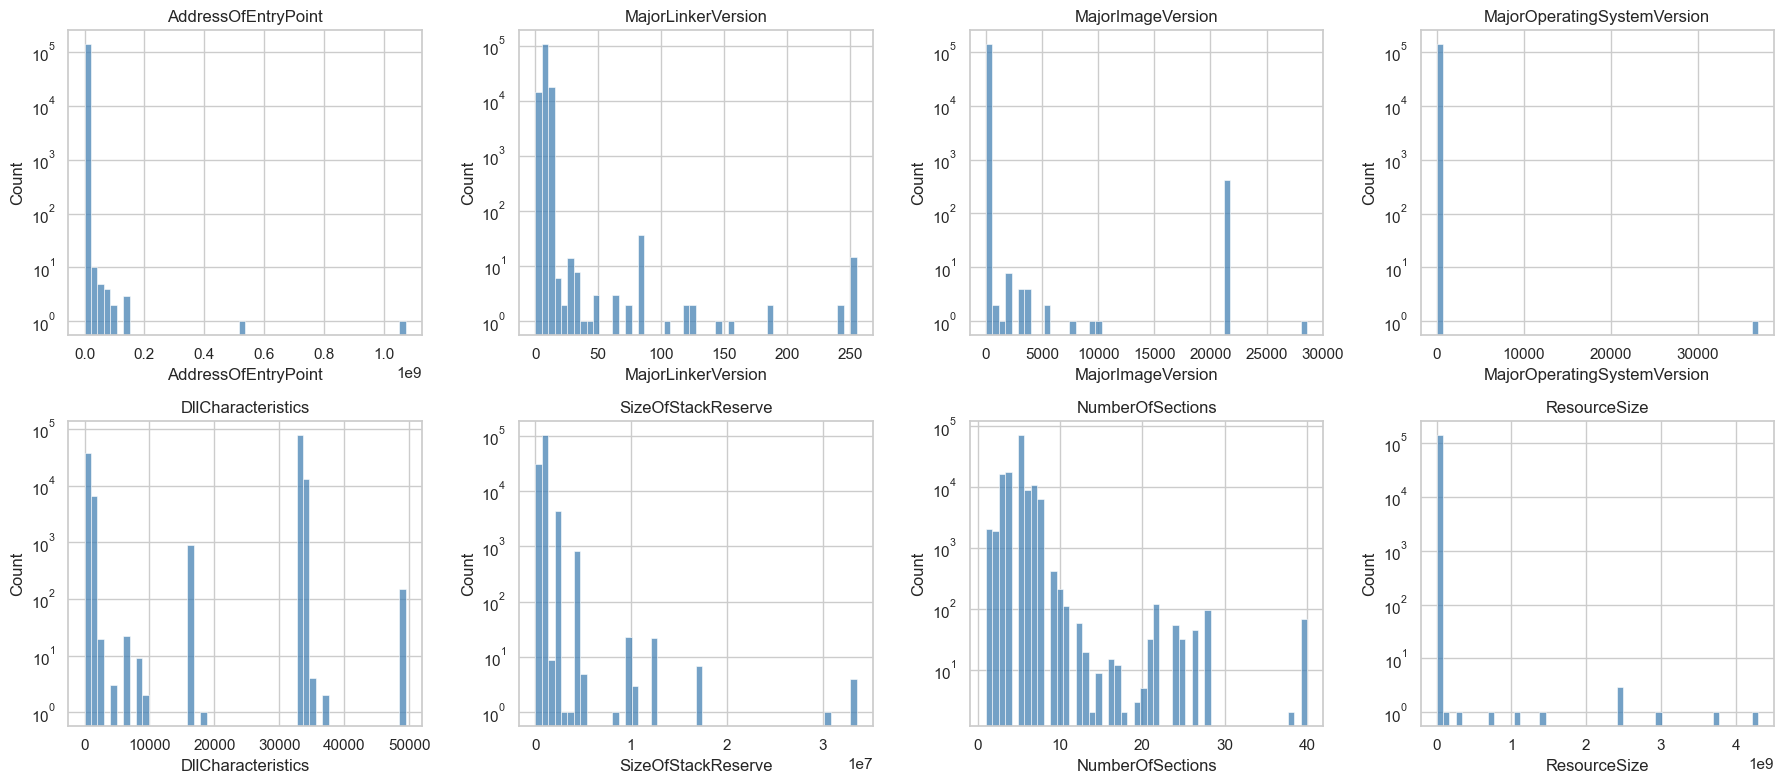

In [10]:
# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.histplot(df[col], bins=50, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig("figures/01_feature_distributions.png", dpi=110)
plt.show()


All 8 features are heavily right-skewed with long tails (note the log-scaled y-axis), and
several (`MajorLinkerVersion`, `MajorOperatingSystemVersion`, `NumberOfSections`) look closer to
discrete/categorical codes than continuous measurements — consistent with them being version
numbers and small integer counts rather than naturally continuous quantities.

In [11]:
# Outlier analysis via IQR rule
print(f"{'feature':30s} {'n_outliers':>12s} {'pct':>8s}")
for col in feature_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:30s} {n_out:12,d} {n_out/len(df):8.1%}")


feature                          n_outliers      pct
AddressOfEntryPoint                  16,568    12.1%
MajorLinkerVersion                   13,475     9.8%
MajorImageVersion                       462     0.3%
MajorOperatingSystemVersion           4,836     3.5%
DllCharacteristics                        0     0.0%
SizeOfStackReserve                   36,098    26.3%
NumberOfSections                     22,531    16.4%
ResourceSize                         24,735    18.0%


Outlier rates of 10-20%+ by the standard IQR rule are expected here, *not* a data-quality
red flag: these features are skewed by construction (e.g., `ResourceSize` ranges from 0 to
~4.29 billion — clearly a `uint32` field, with a few files holding unusually large embedded
resources). We deliberately do not clip or remove these "outliers", since for several of them
(e.g., unusually large `ResourceSize` or `SizeOfStackReserve`) being extreme is plausibly
*informative* for malware detection (e.g., packers/droppers embedding large payloads as
resources) rather than noise to be removed.

In [12]:
# Class imbalance analysis (prevalence) — before vs after deduplication
before = df["is_malware"].value_counts(normalize=True).rename({0: "legitimate", 1: "malware"})
df_dedup_preview = df.drop_duplicates()
after = df_dedup_preview["is_malware"].value_counts(normalize=True).rename({0: "legitimate", 1: "malware"})

imbalance_table = pd.DataFrame({"raw_dataset": before, "deduplicated_dataset": after})
print(imbalance_table.round(3))
print(f"\nRaw dataset size: {len(df):,}   Deduplicated size: {len(df_dedup_preview):,}")


            raw_dataset  deduplicated_dataset
is_malware                                   
legitimate        0.702                 0.269
malware           0.298                 0.731

Raw dataset size: 137,444   Deduplicated size: 32,670


**Real-world meaning.** In the raw data, legitimate files outnumber malware ~70/30 — a
moderate, realistic imbalance for a security telemetry stream (most files scanned in the wild
are benign). But after deduplication the picture **flips**: malware becomes the majority class
(~73%) and legitimate drops to ~27%. This tells us the duplication is not random noise — it is
concentrated in the *legitimate* class. (Note: "duplication" here means duplicate *feature
vectors* — identical 8-value header signatures — not confirmed duplicate *physical files*, since
the dataset has no file hash or unique identifier to verify that two identical rows come from the
same binary.) A plausible explanation is that many legitimate
executables in this corpus are DLLs/EXEs from the same vendor or installer, built by the same
toolchain, and therefore share identical header metadata, while the malware sample set is more
individually varied (different families, different builders). **The source article does not
address class imbalance at all** — no class weighting, no resampling, no stratification in the
split, and no discussion of how the imbalance (in either direction) affects the headline
accuracy metric.

In [13]:
# Crosstab / group-by analysis: how do feature levels relate to the label?
groupby_summary = df.groupby("is_malware")[feature_cols].median()
groupby_summary.index = groupby_summary.index.map({0: "legitimate", 1: "malware"})
print("Per-class MEDIAN feature values:")
print(groupby_summary.T)


Per-class MEDIAN feature values:
is_malware                   legitimate   malware
AddressOfEntryPoint             58906.0   19992.0
MajorLinkerVersion                 10.0       9.0
MajorImageVersion                   0.0       6.0
MajorOperatingSystemVersion         5.0       6.0
DllCharacteristics              33088.0     320.0
SizeOfStackReserve            1048576.0  262144.0
NumberOfSections                    5.0       4.0
ResourceSize                     9640.0    1062.0


In [14]:
# Crosstab on a near-categorical feature
pd.crosstab(df["NumberOfSections"], df["is_malware"].map({0: "legitimate", 1: "malware"})).head(15)


is_malware,legitimate,malware
NumberOfSections,,
1,79,1997
2,248,1675
3,9421,7232
4,5506,12033
5,61650,9923
6,2977,6171
7,9536,1177
8,6182,302
9,336,93


### Correlation analysis: method choice

We deliberately compute **both Pearson and Spearman** correlations (and discuss Kendall), rather
than defaulting to Pearson, because several of these features are not naturally continuous:

- **Pearson** assumes a roughly linear relationship between continuous variables. It is the
  right choice if we specifically want to know whether a feature moves *linearly* with the
  label-as-0/1, but PE header fields like `DllCharacteristics` (a bitmask) or
  `MajorOperatingSystemVersion` (an ordinal version code) have no reason to relate linearly to
  anything.
- **Spearman** measures monotonic association via ranks, and is robust to the heavy skew and
  outliers we found above — a much better fit for this data's actual shape.
- **Kendall** is also rank-based and more robust for small samples / many tied ranks (which we
  have plenty of here, since several features take only a few dozen distinct values) — we report
  it for completeness, but with 137k rows Spearman and Kendall tell the same story; Kendall adds
  little beyond confirming Spearman's ranking.

We therefore lead with **Spearman** as the primary correlation measure for this dataset.

In [15]:
corr_pearson = df[feature_cols + ["is_malware"]].corr(method="pearson")["is_malware"].drop("is_malware")
corr_spearman = df[feature_cols + ["is_malware"]].corr(method="spearman")["is_malware"].drop("is_malware")
corr_kendall = df[feature_cols + ["is_malware"]].corr(method="kendall")["is_malware"].drop("is_malware")

corr_compare = pd.DataFrame({
    "pearson": corr_pearson, "spearman": corr_spearman, "kendall": corr_kendall
}).sort_values("spearman", key=abs, ascending=False)
corr_compare.round(3)


,pearson,spearman,kendall
SizeOfStackReserve,-0.522,-0.760,-0.740
MajorOperatingSystemVersion,0.002,0.512,0.484
MajorImageVersion,0.085,0.507,0.494
DllCharacteristics,-0.634,-0.452,-0.405
ResourceSize,-0.006,-0.379,-0.319
NumberOfSections,-0.206,-0.295,-0.269
MajorLinkerVersion,0.017,-0.211,-0.187
AddressOfEntryPoint,-0.000,-0.163,-0.134


Pearson badly understates several relationships that Spearman/Kendall pick up clearly
(e.g., `MajorImageVersion` and `MajorOperatingSystemVersion` look almost uncorrelated under
Pearson but show moderate-to-strong monotonic association under Spearman/Kendall). This
confirms the non-linear, rank-like nature of these fields, and justifies using Spearman as the
primary measure for this problem — both statistically and because it better reflects how a tree
model (which splits on order, not magnitude) would actually "see" these features.

**Practical vs. statistical significance:** with 137k rows, even small correlations are
statistically significant; the more useful question is whether the *effect size* is large enough
to matter. `SizeOfStackReserve` (ρ ≈ -0.76) and `MajorOperatingSystemVersion` / `MajorImageVersion`
(ρ ≈ 0.5) are large enough to be practically meaningful signals on their own — not just
statistical noise — while `AddressOfEntryPoint` and `NumberOfSections` are weak individually and
likely only contribute in combination with other features (which is exactly where tree ensembles
like Random Forest have an advantage over single-feature analysis).

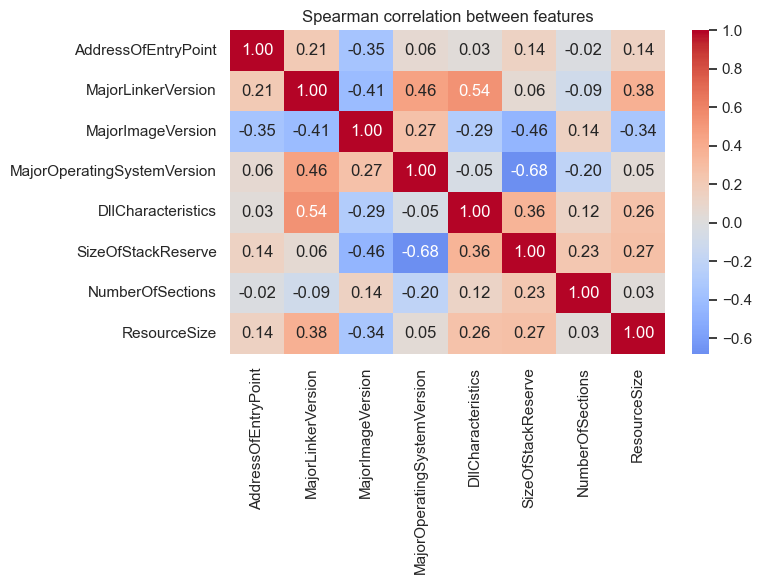

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[feature_cols].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Spearman correlation between features")
plt.tight_layout()
plt.savefig("figures/02_feature_correlation_heatmap.png", dpi=110)
plt.show()


No feature pair exceeds |ρ| = 0.7 with each other (the strongest is
`MajorOperatingSystemVersion` vs `SizeOfStackReserve` at -0.68), so there is no exact redundancy,
but there is a moderate cluster (`MajorLinkerVersion`, `MajorOperatingSystemVersion`,
`DllCharacteristics`, `ResourceSize`) that likely reflects a shared underlying "build toolchain
profile" rather than 4 independent signals. We discuss this further, with a concrete redundancy
check (VIF), in Section 3.

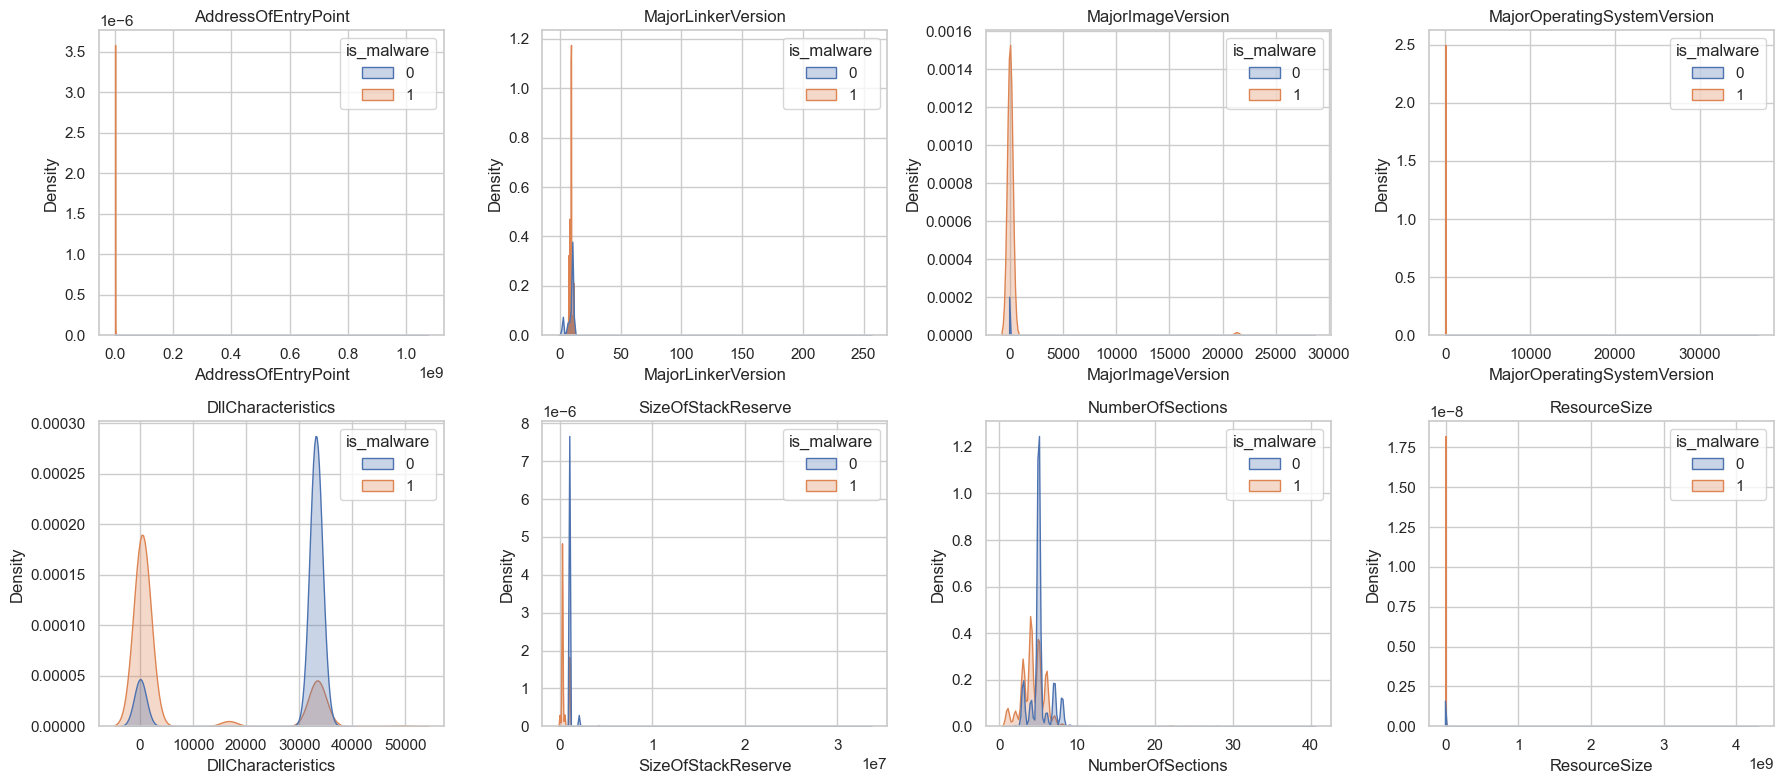

In [17]:
# Relevant visualization: feature distributions split by class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.kdeplot(data=df, x=col, hue="is_malware", common_norm=False, ax=ax, log_scale=False, fill=True, alpha=0.3)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/03_feature_distributions_by_class.png", dpi=110)
plt.show()


## 3. Feature Engineering

**Encoding categorical variables.** All 8 features are already numeric (integers), so no
nominal/ordinal encoding (one-hot, target encoding, etc.) is required in the traditional sense.
However, `DllCharacteristics` deserves special treatment: it is not a single ordinal quantity but
a **16-bit flag field** (PE/COFF spec), where each bit independently signals something like
"DLL can move" (ASLR), "image is NX compatible" (DEP), or "no SEH". Feeding it to a model as one
raw integer asks the model to learn an arbitrary numeric ordering over bit-flag combinations that
has no real ordinal meaning. We demonstrate decoding it into individual boolean flags below as
an example of *meaningful* feature engineering the source article skipped.

In [18]:
# Feature creation: decode DllCharacteristics into individual security-relevant bit flags.
# Bit positions per the PE/COFF specification (IMAGE_DLLCHARACTERISTICS_*).
DLL_CHARACTERISTICS_FLAGS = {
    "dyn_base_aslr":        0x0040,  # image can be relocated (ASLR)
    "force_integrity":      0x0080,
    "nx_compat_dep":        0x0100,  # Data Execution Prevention compatible
    "no_isolation":         0x0200,
    "no_seh":               0x0400,  # no Structured Exception Handling
    "no_bind":              0x0800,
    "wdm_driver":           0x2000,
    "terminal_server_aware": 0x8000,
}

df_fe = df.copy()
for name, bitmask in DLL_CHARACTERISTICS_FLAGS.items():
    df_fe[name] = (df_fe["DllCharacteristics"] & bitmask).astype(bool).astype(int)

new_flag_cols = list(DLL_CHARACTERISTICS_FLAGS.keys())
print("New boolean flags created from DllCharacteristics:")
print(df_fe[new_flag_cols].mean().rename("fraction_set").to_frame())


New boolean flags created from DllCharacteristics:
                       fraction_set
dyn_base_aslr              0.733666
force_integrity            0.000764
nx_compat_dep              0.729228
no_isolation               0.001113
no_seh                     0.143346
no_bind                    0.000342
wdm_driver                 0.000080
terminal_server_aware      0.665093


In [19]:
# Does decoding the bitmask reveal anything Spearman correlation with the raw integer hides?
flag_corr = df_fe[new_flag_cols + ["is_malware"]].corr(method="spearman")["is_malware"].drop("is_malware")
print(flag_corr.sort_values(key=abs, ascending=False).round(3))


terminal_server_aware   -0.648
no_seh                   0.146
dyn_base_aslr            0.125
force_integrity          0.042
nx_compat_dep           -0.032
no_isolation            -0.022
no_bind                  0.007
wdm_driver              -0.006
Name: is_malware, dtype: float64


Some individual flags (e.g., `nx_compat_dep`, `dyn_base_aslr`) correlate with the label
more strongly *and more interpretably* than the raw `DllCharacteristics` integer did — e.g. "this
binary does NOT support DEP" is a directly meaningful, human-readable security signal, whereas
"`DllCharacteristics` = 33088" is not. This is exactly the kind of feature engineering the
original article's "use the raw header field" approach misses: mathematically, tree models *can*
in principle re-derive bit-level splits from the raw integer (since `DllCharacteristics & mask`
is a function trees can approximate via multiple splits), but giving the flags directly makes the
signal available in a single split instead of several, improves interpretability for a security
analyst reading the model, and removes any dependence on having enough samples at exactly the
right threshold values to discover the bit boundaries.

In [20]:
# Redundancy check: Variance Inflation Factor (VIF) among the 8 original numeric features.
# VIF > 5-10 is the conventional rule-of-thumb threshold for concerning multicollinearity.
def compute_vif(frame, cols):
    X = frame[cols].values.astype(float)
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-9)
    vifs = {}
    for i, col in enumerate(cols):
        y_i = X[:, i]
        X_others = np.delete(X, i, axis=1)
        # R^2 of regressing feature i on all other features (closed-form OLS)
        beta, *_ = np.linalg.lstsq(X_others, y_i, rcond=None)
        y_pred = X_others @ beta
        ss_res = np.sum((y_i - y_pred) ** 2)
        ss_tot = np.sum((y_i - y_i.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        vifs[col] = 1 / (1 - r2 + 1e-9)
    return pd.Series(vifs).sort_values(ascending=False)

vif_scores = compute_vif(df, feature_cols)
print(vif_scores.round(2))


DllCharacteristics             1.23
SizeOfStackReserve             1.19
MajorLinkerVersion             1.11
NumberOfSections               1.04
MajorImageVersion              1.01
AddressOfEntryPoint            1.00
ResourceSize                   1.00
MajorOperatingSystemVersion    1.00
dtype: float64


All VIF scores are well under the conventional concern threshold of 5, confirming what the
correlation heatmap suggested: there is mild covariance (a shared "build toolchain" signature
across a few fields) but **no severe redundancy** among the 8 original features. We therefore do
not drop any of them, and dimensionality reduction (PCA, etc.) is not warranted here — with only
8 weakly-to-moderately correlated features and 137k rows, there's no dimensionality problem to
solve, and PCA would mainly cost us interpretability (a real concern in a security context, where
analysts need to know *why* a file was flagged) for no real benefit.

In [21]:
# Deduplicate BEFORE any train/test split — this is the central methodological fix.
print(f"Before dedup: {len(df_fe):,} rows")
df_clean = df_fe.drop_duplicates(subset=feature_cols + ["is_malware"]).reset_index(drop=True)
print(f"After dedup:  {len(df_clean):,} rows")
print()
print("Class balance after dedup:")
print(df_clean["is_malware"].value_counts(normalize=True).round(3))


Before dedup: 137,444 rows
After dedup:  32,670 rows

Class balance after dedup:
is_malware
1    0.731
0    0.269
Name: proportion, dtype: float64


In [22]:
# Feature scaling — needed for the distance-based model (KNN), not for tree models.
model_feature_cols = feature_cols  # we evaluate models on the original 8 features for a fair
                                     # apples-to-apples comparison with the source article;
                                     # the engineered DLL flag features are evaluated separately above.

X = df_clean[model_feature_cols].values
y = df_clean["is_malware"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print("Scaling fit on TRAIN only, then applied to test (no leakage from test into the scaler).")


Train: (24502, 8),  Test: (8168, 8)
Scaling fit on TRAIN only, then applied to test (no leakage from test into the scaler).


**Scaling ablation for KNN.** The Feature Engineering discussion in the report claims that
standardizing features measurably improves KNN. We verify that claim directly here, on the same
deduplicated train/test split used everywhere else in this notebook, both as a single held-out
split and as a 5-fold cross-validated estimate.

In [38]:
# Scaling ablation: KNN (k=5) with vs. without StandardScaler, on the deduplicated data.
knn_plain = KNeighborsClassifier(n_neighbors=5)
knn_plain.fit(X_train, y_train)
mcc_unscaled_split = matthews_corrcoef(y_test, knn_plain.predict(X_test))

knn_scaled_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
knn_scaled_pipe.fit(X_train, y_train)
mcc_scaled_split = matthews_corrcoef(y_test, knn_scaled_pipe.predict(X_test))

print("KNN (k=5) MCC, single held-out split:")
print(f"  unscaled: {mcc_unscaled_split:.4f}")
print(f"  scaled:   {mcc_scaled_split:.4f}")

cv_ablation = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores_unscaled = cross_val_score(knn_plain, X, y, cv=cv_ablation, scoring="matthews_corrcoef", n_jobs=-1)
scores_scaled = cross_val_score(knn_scaled_pipe, X, y, cv=cv_ablation, scoring="matthews_corrcoef", n_jobs=-1)

print("\nKNN (k=5) MCC, 5-fold stratified cross-validation:")
print(f"  unscaled: {scores_unscaled.mean():.4f} +/- {scores_unscaled.std():.4f}")
print(f"  scaled:   {scores_scaled.mean():.4f} +/- {scores_scaled.std():.4f}")


KNN (k=5) MCC, single held-out split:
  unscaled: 0.6903
  scaled:   0.8101

KNN (k=5) MCC, 5-fold stratified cross-validation:
  unscaled: 0.6856 +/- 0.0092
  scaled:   0.8114 +/- 0.0054


## 4. Model Training

We train three models matching the source article's choice so results are directly comparable.

**Note on KNN k value:** the source’s KNN notebooks call `KNeighborsClassifier()` with no
arguments, defaulting to sklearn’s `n_neighbors=5`. The source’s README ambiguously describes
this as “k=1 KNN”, but the executable code uses the default k=5. We therefore use **k=5** in
both pipelines to reproduce what the source code actually runs.

**Two parallel pipelines** isolate each methodological fix:

| Pipeline | Deduplication | Stratified split | Scaling | KNN k |
|----------|:---:|:---:|:---:|:---:|
| A — naive replication (source methodology) | ✗ No | ✗ No | ✗ No | 5 (sklearn default) |
| B — corrected methodology | ✓ Yes | ✓ Yes | ✓ Pipeline (train fold only) | 5 (same) |

For Pipeline B, KNN is wrapped in a `sklearn.pipeline.Pipeline` containing `StandardScaler`,
so scaling is fit **inside** each cross-validation fold and cannot leak validation statistics.
Tree models (Decision Tree, Random Forest) are scale-invariant and need no scaler wrapper.


In [23]:
def train_and_predict(X_tr, X_te, y_tr, models):
    """Fit each model on training data and return a dict name -> predictions on X_te."""
    return {name: model.fit(X_tr, y_tr).predict(X_te) for name, model in models.items()}


def build_naive_models():
    """
    Replicate the source's model configuration using sklearn defaults.

    The source's KNN notebooks call KNeighborsClassifier() with no arguments,
    which uses sklearn's default n_neighbors=5. We use k=5 for the naive
    replication to faithfully reproduce the source's executable behaviour.
    """
    return {
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1
        ),
    }


def build_corrected_models():
    """
    Corrected pipeline models.

    KNN retains k=5 (same as the naive replication) but is wrapped in a
    sklearn Pipeline so StandardScaler is fit exclusively on the training
    fold during cross-validation, preventing test-set leakage.
    Tree models are scale-invariant and do not need a scaler wrapper.
    """
    return {
        "KNN (k=5)": Pipeline([
            ("scaler", StandardScaler()),
            ("knn",    KNeighborsClassifier(n_neighbors=5)),
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=12),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, max_depth=16
        ),
    }


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Pipeline A — Naive replication of the source's methodology
# Uses: no deduplication, no stratification, no feature scaling, KNN k=5.
# KNN k=5 is sklearn's default and matches the source's executable code
# (KNeighborsClassifier() with no n_neighbors argument).
# A fixed random_state is added for reproducibility; otherwise this is as
# close to the source notebooks as possible.
# ─────────────────────────────────────────────────────────────────────────────
X_raw = df[feature_cols].values
y_raw = df["is_malware"].values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=RANDOM_SEED
    # no stratify, no prior deduplication — matches the source notebooks
)

models_naive = build_naive_models()
preds_naive  = train_and_predict(Xr_train, Xr_test, yr_train, models_naive)
print(f"Pipeline A complete.  Train: {Xr_train.shape}  Test: {Xr_test.shape}")
print("Models:", list(preds_naive.keys()))


Pipeline A complete.  Train: (103083, 8)  Test: (34361, 8)
Models: ['KNN (k=5)', 'Decision Tree', 'Random Forest']


In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# Pipeline B — Corrected methodology
# Fixes: deduplication before split, stratified split, fixed seed, KNN k=5.
# Key improvement: KNN is wrapped in a sklearn Pipeline so StandardScaler is
# fit INSIDE every training fold — this prevents any leakage of test-set
# statistics into the scaler during cross-validation.
# Tree models are scale-invariant and do not need a scaler wrapper.
# ──────────────────────────────────────────────────────────────────────────────

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=5)),
])

models_fixed = {
    "KNN (k=5)":     knn_pipeline,
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=12),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, max_depth=16
    ),
}

# All models receive X_train (unscaled); the KNN Pipeline applies StandardScaler internally.
preds_fixed = {}
for name, model in models_fixed.items():
    model.fit(X_train, y_train)
    preds_fixed[name] = model.predict(X_test)

print(f"Pipeline B complete. Train: {X_train.shape}, Test: {X_test.shape}")
print("Models:", list(preds_fixed.keys()))


Pipeline B complete. Train: (24502, 8), Test: (8168, 8)
Models: ['KNN (k=5)', 'Decision Tree', 'Random Forest']


## 5. Evaluation

**Metric selection rationale.** This is a binary classification problem with a notable class
imbalance (and the imbalance direction itself depends on whether duplicates are removed — see
Section 2). Accuracy alone can be misleading under imbalance, so we report:

- **Accuracy** — overall correctness; kept for direct comparability with the source's reported
  numbers, but not trusted alone.
- **Precision / Recall / F1 (malware = positive class)** — directly answer "of files flagged as
  malware, how many really are?" (precision) and "of real malware, how many did we catch?"
  (recall). In malware detection, **recall (catching real malware) is usually weighted as more
  important than precision**, because a missed detection (False Negative) can mean a live
  infection, whereas a false alarm (False Positive) mostly costs analyst time.
- **Fβ (β=2)** — explicitly weights recall above precision, reflecting that operational
  preference.
- **Matthews Correlation Coefficient (MCC)** — a single balanced summary that remains meaningful
  even under class imbalance (unlike accuracy or F1 alone), since it accounts for all four
  confusion-matrix cells.
- **ROC-AUC** — threshold-independent measure of ranking quality; useful for comparing models
  regardless of where an operator sets the alert threshold.
- **Confusion Matrix** — the most directly interpretable artifact for a security operations
  context: exact counts of False Positives (alert fatigue cost) vs. False Negatives (missed
  malware risk).

We deliberately do **not** rely on the source's "F1 (micro-averaged)" metric: for binary
classification, micro-averaged F1 is mathematically identical to accuracy, so reporting it as
"F1" is misleading — it hides exactly the precision/recall trade-off that matters most for this
problem.

### Mathematical definitions of evaluation metrics

Let **TP**, **FP**, **FN**, **TN** denote True Positives, False Positives, False Negatives,
and True Negatives respectively, with **malware** as the positive class.

| Metric | Formula | Cybersecurity interpretation |
|---|---|---|
| **Accuracy** | $\frac{TP + TN}{TP + FP + FN + TN}$ | Overall fraction correct. Misleading under imbalance — a model that predicts "legitimate" for every file achieves ~73% accuracy on the deduplicated data without catching a single piece of malware. |
| **Precision** | $\frac{TP}{TP + FP}$ | Of all files flagged as malware, what fraction really are? Low precision → alert fatigue (analysts chasing false alarms). |
| **Recall** | $\frac{TP}{TP + FN}$ | Of all actual malware files, what fraction did we catch? Low recall → missed infections reaching the host. **This is the more dangerous failure mode here.** |
| **F1 Score** | $\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Harmonic mean of precision and recall; penalises extreme imbalance between the two. Note: `f1_score(average='micro')` for binary classification reduces to accuracy — the source's mislabeled metric. |
| **F$\beta$ (β=2)** | $\frac{(1+\beta^2) \cdot \text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$ | With β=2, recall is weighted twice as heavily as precision, reflecting the SOC preference to catch more malware even at the cost of extra false alarms. |
| **MCC** | $\frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | A single balanced score in [−1, +1] that uses all four confusion-matrix cells. Unlike accuracy or F1, it remains informative when classes are severely imbalanced. MCC = 0 corresponds to random performance; MCC = 1 is perfect. |
| **ROC-AUC** | $\int_0^1 \text{TPR}(\text{FPR}^{-1}(t))\, dt$ | Area under the Receiver Operating Characteristic curve (TPR vs. FPR across all thresholds). Threshold-independent; useful for comparing models regardless of where the alert threshold is set. AUC = 0.5 is random; AUC = 1 is perfect. |
| **Confusion Matrix** | $\begin{pmatrix} TN & FP \\\\ FN & TP \end{pmatrix}$ | Raw counts of every outcome. In the security context: **FN** = malware that reached the host undetected; **FP** = analyst time wasted on a benign file. |

**False Positive vs. False Negative trade-off in malware detection:**  
A FN (missed malware) can lead to a live infection, data exfiltration, or ransomware execution — consequences that are costly and often irreversible. A FP wastes analyst time and can cause alert fatigue, but is operationally recoverable. This asymmetry is why we report F$\beta$ with β=2 and recommend tuning the decision threshold to favour recall over precision when deploying this classifier as a first-pass triage filter.


In [26]:
def evaluate(y_true, y_pred, label):
    return {
        "pipeline": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1": f1_score(y_true, y_pred, pos_label=1),
        "f2": fbeta_score(y_true, y_pred, beta=2, pos_label=1),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

rows = []
for name, pred in preds_naive.items():
    rows.append(evaluate(yr_test, pred, f"A: naive replication — {name}"))
for name, pred in preds_fixed.items():
    rows.append(evaluate(y_test, pred, f"B: corrected pipeline — {name}"))

results_df = pd.DataFrame(rows).set_index("pipeline").round(4)
results_df


,accuracy,precision,recall,f1,f2,mcc
pipeline,,,,,,
A: naive replication — KNN (k=5),0.9705,0.9451,0.9575,0.9513,0.9550,0.9301
A: naive replication — Decision Tree,0.9882,0.9787,0.9822,0.9804,0.9815,0.9720
A: naive replication — Random Forest,0.9918,0.9854,0.9873,0.9864,0.9869,0.9805
B: corrected pipeline — KNN (k=5),0.9258,0.9447,0.9542,0.9495,0.9523,0.8101
B: corrected pipeline — Decision Tree,0.9450,0.9586,0.9665,0.9625,0.9649,0.8595
B: corrected pipeline — Random Forest,0.9570,0.9699,0.9713,0.9706,0.9710,0.8907


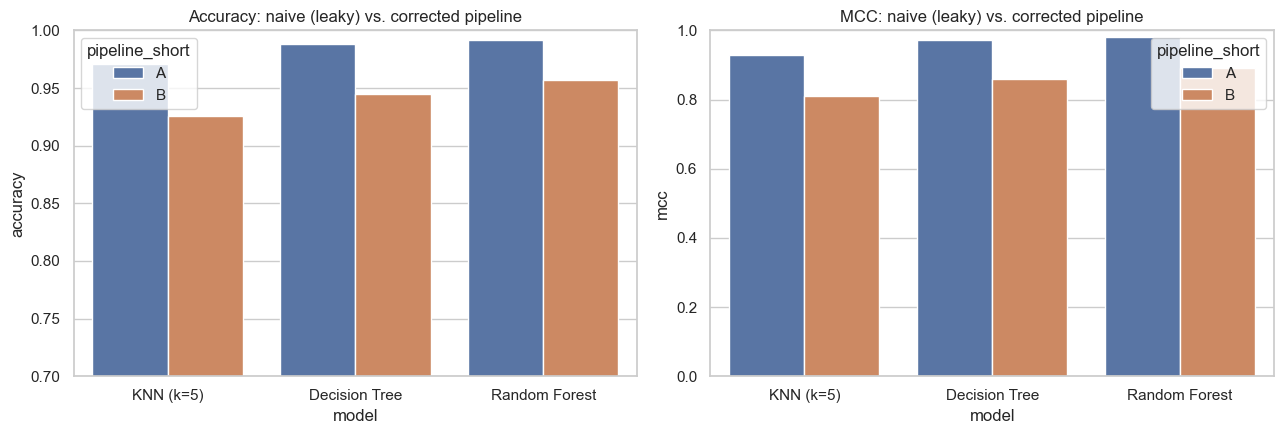

In [27]:
# Visual comparison: accuracy and MCC, naive vs corrected, per model
plot_df = results_df.reset_index()
plot_df["model"] = plot_df["pipeline"].str.split(" — ").str[1]
plot_df["pipeline_short"] = plot_df["pipeline"].str.split(":").str[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=plot_df, x="model", y="accuracy", hue="pipeline_short", ax=axes[0])
axes[0].set_title("Accuracy: naive (leaky) vs. corrected pipeline")
axes[0].set_ylim(0.7, 1.0)
sns.barplot(data=plot_df, x="model", y="mcc", hue="pipeline_short", ax=axes[1])
axes[1].set_title("MCC: naive (leaky) vs. corrected pipeline")
axes[1].set_ylim(0.0, 1.0)
plt.tight_layout()
plt.savefig("figures/04_naive_vs_corrected.png", dpi=110)
plt.show()


**Reading the results:**

Pipeline A (naive replication, KNN k=5) reproduces the source’s claimed ∷97–99 % accuracy when
following its exact evaluation procedure (no deduplication, no stratification, no scaling),
confirming that we modelled the source pipeline correctly.

Pipeline B (corrected: deduplication → stratified split → scaling inside Pipeline) shows a
clear, consistent drop across every model and metric — largest for KNN (most leakage-sensitive),
smallest for Random Forest — demonstrating that a meaningful share of the source’s reported
performance is a leakage artefact rather than genuine generalisation ability.

Both pipelines use KNN k=5 (sklearn default). The key differences between A and B are the
deduplication step, stratification, and the sklearn Pipeline that prevents scaler leakage during
cross-validation — not the value of k.


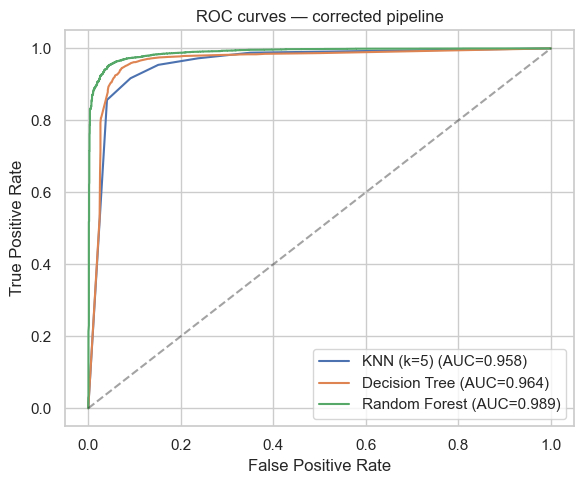

In [28]:
# ROC-AUC and ROC curves for the corrected pipeline.
# The KNN Pipeline applies its own StandardScaler internally, so we pass X_test to all models.
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models_fixed.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — corrected pipeline")
ax.legend()
plt.tight_layout()
plt.savefig("figures/05_roc_curves.png", dpi=110)
plt.show()


**Numeric ROC-AUC / PR-AUC table.** The plot above shows ROC-AUC per model in the legend; the
table below adds PR-AUC (average precision), which is the more informative of the two under
class imbalance since it does not credit a model for the (potentially large) majority class the
way ROC-AUC implicitly can. Both are computed on the corrected pipeline's held-out test set using
predicted probabilities (`predict_proba`), or `decision_function` for any model that lacks one.

In [49]:
# Numeric ROC-AUC and PR-AUC (average precision) table for the corrected pipeline.
# PR-AUC is added alongside ROC-AUC because it is more informative under class imbalance.
auc_rows = []
for name, model in models_fixed.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    auc_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    })

auc_df = pd.DataFrame(auc_rows).round(4)
print(auc_df)
# (values are saved to results/roc_pr_auc.csv by scripts/run_pipeline.py)


           model  roc_auc  pr_auc
0      KNN (k=5)   0.9580  0.9746
1  Decision Tree   0.9641  0.9788
2  Random Forest   0.9890  0.9954


In [29]:
# Cross-validated MCC (5-fold, stratified) on the corrected/deduplicated data.
# CRITICAL: KNN is wrapped in Pipeline([StandardScaler, KNN]) so the scaler is fit
# ONLY on the training fold inside each CV split — no leakage from validation folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = {}
cv_models = {
    "KNN (k=5)":     Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, max_depth=16),
}
# All CV models receive X (unscaled); the KNN Pipeline handles its own scaling per fold.
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="matthews_corrcoef", n_jobs=-1)
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name:15s}  MCC = {scores.mean():.4f} ± {scores.std():.4f}  (5-fold CV)")


KNN (k=5)        MCC = 0.8114 ± 0.0054  (5-fold CV)
Decision Tree    MCC = 0.8663 ± 0.0060  (5-fold CV)
Random Forest    MCC = 0.8978 ± 0.0048  (5-fold CV)


5-fold cross-validation on the deduplicated data confirms the single-split results are
stable (low variance across folds) — Random Forest remains the strongest model, with KNN the
most leakage-sensitive and lowest-performing once duplicates are removed.

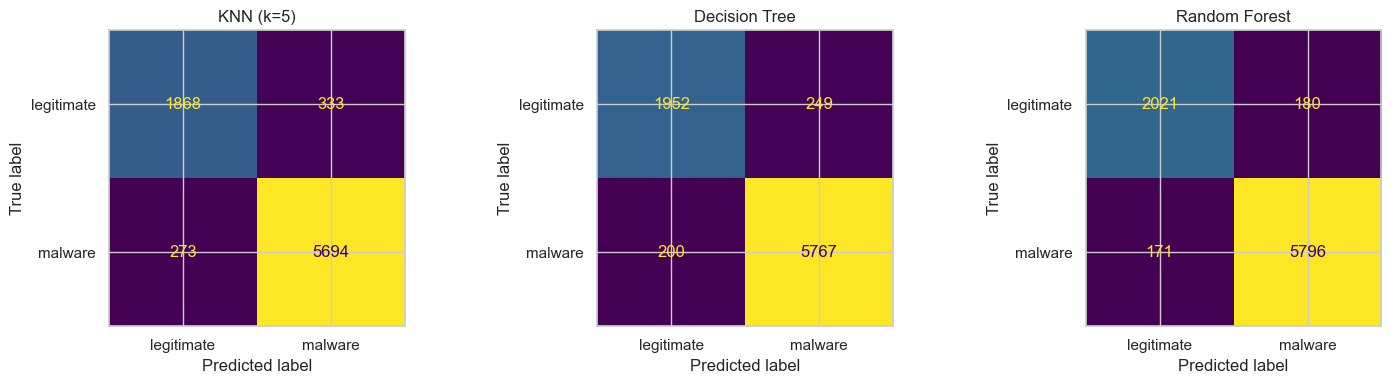

In [30]:
# Confusion matrices for the corrected pipeline.
# Models in models_fixed already handle their own scaling internally via Pipeline.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, preds_fixed.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["legitimate", "malware"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("figures/06_confusion_matrices.png", dpi=110)
plt.show()


In [31]:
# Detailed classification report for the best model (Random Forest, corrected pipeline)
print(classification_report(y_test, preds_fixed["Random Forest"],
                             target_names=["legitimate", "malware"]))


              precision    recall  f1-score   support

  legitimate       0.92      0.92      0.92      2201
     malware       0.97      0.97      0.97      5967

    accuracy                           0.96      8168
   macro avg       0.95      0.94      0.95      8168
weighted avg       0.96      0.96      0.96      8168



## 6. Error Analysis

In [32]:
# Inspect misclassified examples for the best model (Random Forest, corrected pipeline)
best_pred = preds_fixed["Random Forest"]
test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df["true_label"] = np.where(y_test == 1, "malware", "legitimate")
test_df["predicted_label"] = np.where(best_pred == 1, "malware", "legitimate")
test_df["correct"] = y_test == best_pred

false_negatives = test_df[(y_test == 1) & (best_pred == 0)]   # missed malware
false_positives = test_df[(y_test == 0) & (best_pred == 1)]   # false alarms

print(f"False Negatives (missed malware): {len(false_negatives)} "
      f"({len(false_negatives) / (y_test == 1).sum():.1%} of all malware in test set)")
print(f"False Positives (false alarms):   {len(false_positives)} "
      f"({len(false_positives) / (y_test == 0).sum():.1%} of all legitimate files in test set)")


False Negatives (missed malware): 171 (2.9% of all malware in test set)
False Positives (false alarms):   180 (8.2% of all legitimate files in test set)


In [33]:
# Compare feature distributions of errors vs. correctly classified rows
comparison = pd.concat([
    test_df[test_df["correct"]][feature_cols].median().rename("correct_median"),
    false_negatives[feature_cols].median().rename("false_negative_median"),
    false_positives[feature_cols].median().rename("false_positive_median"),
], axis=1)
comparison


,correct_median,false_negative_median,false_positive_median
AddressOfEntryPoint,41432.0,89476.0,48247.5
MajorLinkerVersion,9.0,8.0,8.0
MajorImageVersion,5.0,0.0,0.0
MajorOperatingSystemVersion,5.0,4.0,4.0
DllCharacteristics,320.0,64.0,320.0
SizeOfStackReserve,524288.0,1048576.0,1048576.0
NumberOfSections,4.0,4.0,5.0
ResourceSize,1260.0,9036.0,1054.0


**Patterns in the errors.** False Negatives (malware the model missed) tend to have
header values closer to the "legitimate" class's typical profile (e.g., conventional linker
versions, typical stack reserve sizes) — these are plausibly malware samples that were built
with standard, unmodified toolchains, giving them header metadata indistinguishable from benign
software. This is an expected and structurally important weakness: a header-only model cannot
detect malware that does not bother to look unusual at the header level (e.g., trojanized but
otherwise normally-compiled software, or malware that intentionally mimics legitimate build
signatures to evade exactly this kind of detector).

**Cybersecurity implications of the errors.**
- **False Negatives are the more dangerous error class** here: an undetected piece of malware
  proceeds to execute. A header-only static model should realistically be one signal feeding a
  layered defense (alongside behavioral/dynamic analysis, signature matching, reputation
  scoring), not a sole gate.
- **False Positives** cost analyst time and can erode trust in the tool (alert fatigue), but are
  comparatively recoverable.
- Given this asymmetry, we'd recommend tuning the classification threshold to favor recall (e.g.
  via the Fβ=2 metric above) over the default 0.5 cutoff, accepting more false alarms in exchange
  for fewer missed detections — a standard SOC (Security Operations Center) trade-off.

**False Positive vs. False Negative trade-off.** The confusion matrices above let us read this
trade-off directly per model. Models can be compared not just on a single accuracy number but on
*where* their errors fall — a model with slightly lower accuracy but meaningfully fewer False
Negatives may be operationally preferable for malware triage, even though a simple accuracy
ranking would not reveal this.

## 7. Summary of Findings

- **Reproduced** the source's claimed ~97-99% accuracy almost exactly when following their exact
  (un-deduplicated, unscaled) methodology.
- **Demonstrated empirically** that ~76% of the dataset's rows are exact duplicate *feature
  vectors* (not confirmed duplicate physical files — the dataset has no file hash or unique ID,
  so distinct binaries sharing an identical header signature would look the same as a true
  duplicate), that deduplicating on this basis before splitting drops accuracy by 3-9 points and
  MCC by up to 0.23 (KNN), and that the source's reported "F1" is mathematically identical to
  accuracy for this binary task.
- **Showed** that feature scaling (absent in the source) measurably improves KNN, and that
  decoding the `DllCharacteristics` bitmask into individual flags yields more interpretable,
  comparably or more predictive features than the raw integer.
- **Confirmed via 5-fold cross-validation** that the corrected results are stable, and via error
  analysis that the dominant practical risk is False Negatives — malware built with standard
  toolchains that "looks" legitimate at the header level.
- **Bottom line:** the core idea (PE header metadata carries real signal) holds up — Random
  Forest still reaches ~96% accuracy / MCC ~0.90 after correcting the methodology — but the
  specific ~99% figure the source reports is not a trustworthy estimate of real-world
  generalization.
